# Simple Linear Regression #

### Treasury Bonds Holdings vs. US Dollar Index ###

In [1]:
# Import Libraries

# Data Management
import pandas as pd
import numpy as np

# Statistics
import statsmodels.api as sm 
import matplotlib.pyplot as plt

# Get Data
from fredapi import Fred

In [2]:
# Data Collection Function from FRED
def get_fred_data(symbol: str) -> pd.DataFrame:
    
    # Here you write the API key you got from the FRED website.
    fred_key = '28a2f98efd0d54f81450478a9b3a2e32'

    fred = Fred(api_key = fred_key)
    
    df = fred.get_series(symbol)
    
    return df

In [3]:
# Data for Y (Memorandum Items: Custody Holdings: Marketable U.S. Treasury Securities: Wednesday Level)
y = get_fred_data('WMTSECL1')

# Creating Time Index
y.index = pd.to_datetime(y.index)

y

2002-12-18          0.0
2002-12-25          0.0
2003-01-01          0.0
2003-01-08          0.0
2003-01-15          0.0
                ...    
2025-10-22    2750845.0
2025-10-29    2787185.0
2025-11-05    2769212.0
2025-11-12    2745407.0
2025-11-19    2737528.0
Length: 1197, dtype: float64

In [4]:
# Data for Explanatory Variables (Nominal Broad U.S. Dollar Index)
x = get_fred_data('DTWEXBGS')

# Time Index
x.index = pd.to_datetime(x.index)

x

2006-01-02    101.4155
2006-01-03    100.7558
2006-01-04    100.2288
2006-01-05    100.2992
2006-01-06    100.0241
                ...   
2025-11-17    121.5131
2025-11-18    121.6042
2025-11-19    121.8845
2025-11-20    122.0735
2025-11-21    122.2350
Length: 5190, dtype: float64

In [5]:
# Create the Data for Lineal Regression
ols_df = pd.DataFrame({'x': x, 'y': y})

# Eliminate 0s
ols_df = ols_df[(ols_df['x'] > 0) & (ols_df['y'] > 0)]

# Cut the Sample
ols_df = ols_df["2018-01-01":]

ols_df

,x,y
2018-01-03,109.6751,3014079.0
2018-01-10,109.6277,3017693.0
2018-01-17,108.1526,3017984.0
2018-01-24,107.0801,3013396.0
2018-01-31,106.7695,3032653.0
...,...,...
2025-10-22,121.3075,2750845.0
2025-10-29,120.9290,2787185.0
2025-11-05,122.2295,2769212.0
2025-11-12,121.4459,2745407.0


In [6]:
# We use Natural Log to calculate better betas
log_ols_df = np.log(ols_df)

# Drop NaNs
log_ols_df = log_ols_df.dropna()

# Set Index as a Date Item
log_ols_df.index = pd.to_datetime(log_ols_df.index)

log_ols_df

,x,y
2018-01-03,4.697522,14.918805
2018-01-10,4.697090,14.920003
2018-01-17,4.683543,14.920100
2018-01-24,4.673577,14.918578
2018-01-31,4.670672,14.924948
...,...,...
2025-10-22,4.798329,14.827419
2025-10-29,4.795204,14.840543
2025-11-05,4.805900,14.834073
2025-11-12,4.799469,14.825440


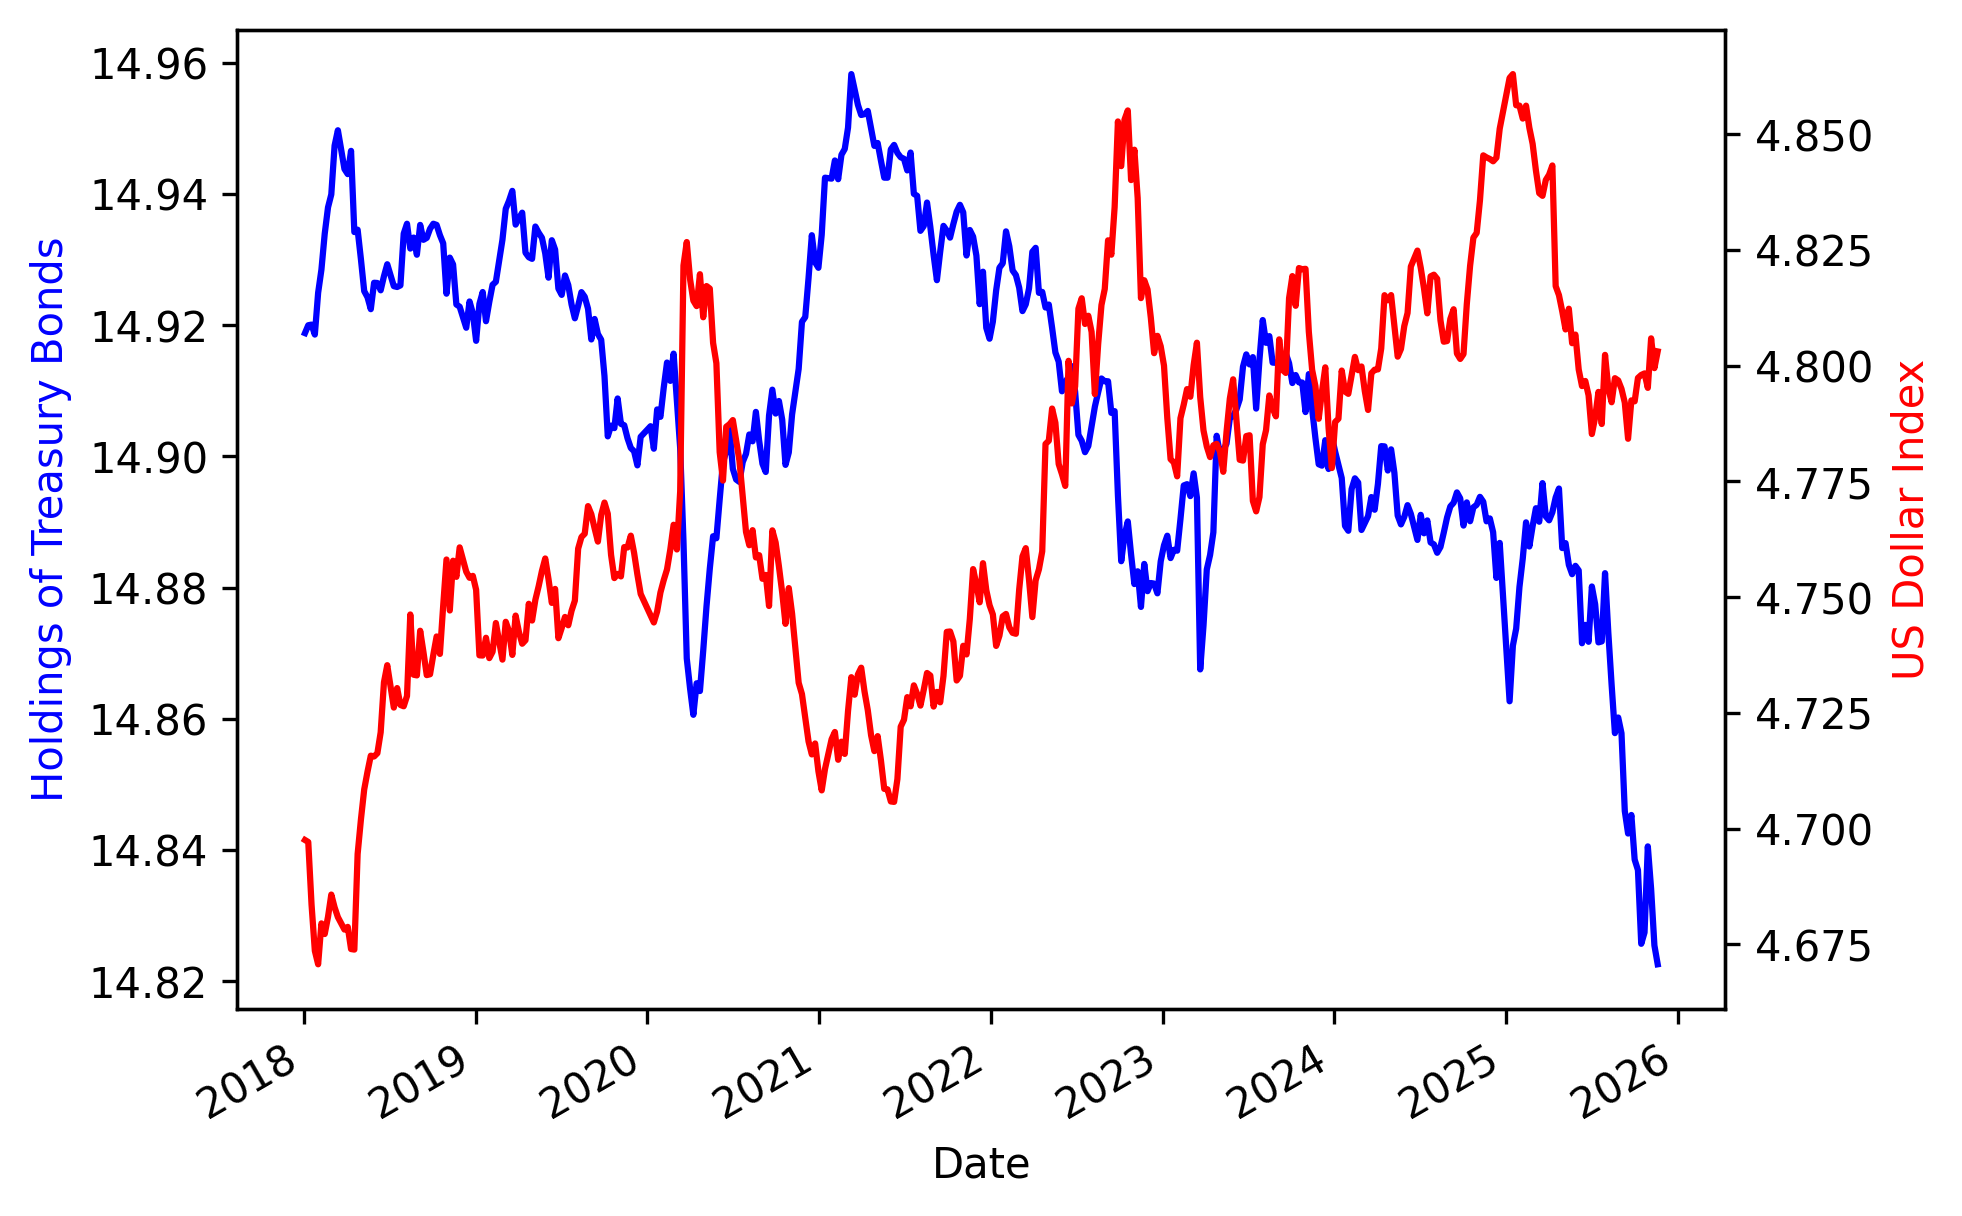

In [7]:
"""
By Plotting the Variables we might understand the relations among them
"""

# Create Figure
fig, ax1 = plt.subplots(dpi = 300)

# Holdings of Treasury Bonds Plot
log_ols_df['y'].plot(color = 'blue', ax = ax1)
ax1.set_xlabel('Date')
ax1.set_ylabel(
    'Holdings of Treasury Bonds', 
    color='blue'
    )

# US Dollar Index Plot
ax2 = ax1.twinx()

log_ols_df['x'].plot(color = 'red', ax = ax2)
ax2.set_ylabel(
    'US Dollar Index', 
    color='red'
    )

plt.show()

Correlation Coefficient:

1) $ \rho_{x,y}=\frac{Cov(x,y)}{\sigma_x\sigma_y} $

In [8]:
# Calculate correlation 
correlation = log_ols_df['y'].corr(log_ols_df['x'])

print(f"\nPearson Correlation Coefficient: {correlation}")


Pearson Correlation Coefficient: -0.7372591535679841


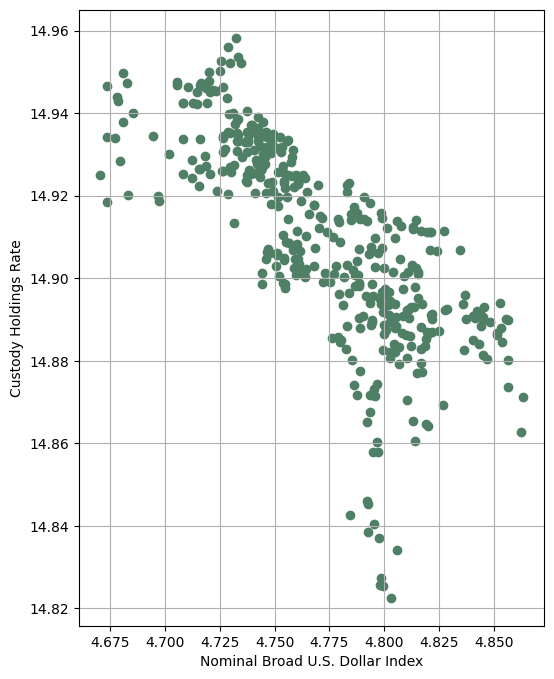

In [29]:
# Scatter Plot
plt.figure(figsize=(6, 8))
plt.scatter(log_ols_df['x'], log_ols_df['y'], color='#4F7F64')
plt.ylabel('Custody Holdings Rate')
plt.xlabel('Nominal Broad U.S. Dollar Index')

# Grid
plt.grid(True)

# Save
plt.savefig(r"..\plots\scatter_plot.jpg", dpi=300, bbox_inches="tight")

# Show
plt.show()

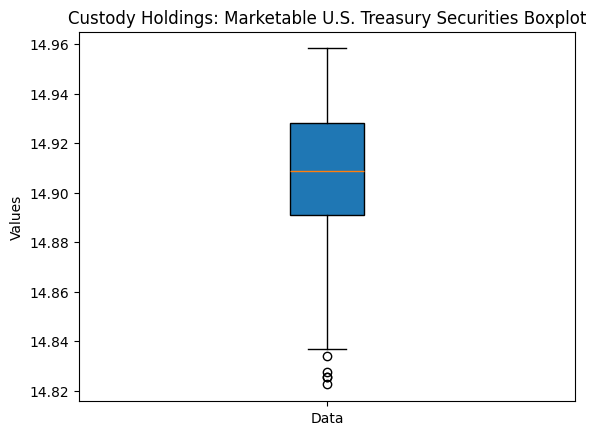

In [10]:
# Create a Box Plot to identify Outliers
plt.boxplot(log_ols_df['y'], vert=True, patch_artist=True)  

# Config
plt.title("Custody Holdings: Marketable U.S. Treasury Securities Boxplot")
plt.ylabel("Values")
plt.xticks([1], ["Data"]) 

plt.show()

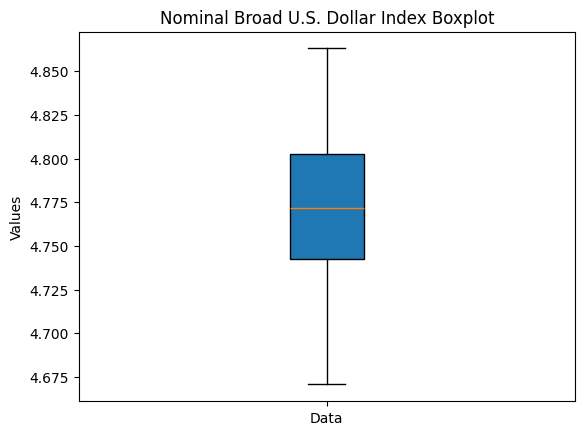

In [11]:
# Create a Box Plot to identify Outliers
plt.boxplot(log_ols_df['x'], vert=True, patch_artist=True)  

# Config
plt.title("Nominal Broad U.S. Dollar Index Boxplot")
plt.ylabel("Values")
plt.xticks([1], ["Data"]) 

plt.show()

In [12]:
# Let us eliminate those values on the Unemployment Rate Growth Rate that exceeds 3 Standard Deviations
inferior_limit = log_ols_df['y'].mean() - 3 * log_ols_df['y'].std()
superior_limit = log_ols_df['y'].mean() + 3 * log_ols_df['y'].std()

# Filter outliers
ols_df_filtered = log_ols_df[(log_ols_df["y"] >= inferior_limit) & (log_ols_df["y"] <= superior_limit)]

ols_df_filtered

,x,y
2018-01-03,4.697522,14.918805
2018-01-10,4.697090,14.920003
2018-01-17,4.683543,14.920100
2018-01-24,4.673577,14.918578
2018-01-31,4.670672,14.924948
...,...,...
2025-09-24,4.792499,14.845330
2025-10-01,4.792299,14.838525
2025-10-08,4.797346,14.836926
2025-10-29,4.795204,14.840543


In [13]:
"""
In a Linear Regression Model it is fundamental to have a Constant Value
This can be expressed as a Vertical Vector of 1's'
"""

ols_df_filtered = sm.add_constant(ols_df_filtered)

ols_df_filtered

,const,x,y
2018-01-03,1.0,4.697522,14.918805
2018-01-10,1.0,4.697090,14.920003
2018-01-17,1.0,4.683543,14.920100
2018-01-24,1.0,4.673577,14.918578
2018-01-31,1.0,4.670672,14.924948
...,...,...,...
2025-09-24,1.0,4.792499,14.845330
2025-10-01,1.0,4.792299,14.838525
2025-10-08,1.0,4.797346,14.836926
2025-10-29,1.0,4.795204,14.840543


The simple Linear Regression Model is expressed in the next form:

1) $ y=\beta_0+\beta_1x+\varepsilon $

This is the population version of the LRM. The Sample version implies estimated coefficient:

2) $ \hat{y}=\hat{\beta}_0+\hat{\beta}_1x+\varepsilon $

After solving an optimization problem, we can calculate the betas using the next expressions:

3) $ \hat{\beta_0}=\bar{y}-\hat{\beta_1}\bar{x} $
4) $ \hat{\beta_1}=\frac{\sum{xy}-\bar{x}\bar{y}}{\sum{x^2}-\bar{x}^2}=\frac{Cov(x,y)}{Var(x)} $

In [14]:
# Getting Variance and Covariance
covariance = ols_df_filtered['y'].cov(ols_df_filtered['x'])
variance = ols_df_filtered['x'].var()

print(f"Covariance: {covariance}")
print(f"Variance: {variance}")

Covariance: -0.0007412719308233615
Variance: 0.0017079289130416534


In [15]:
# Getting Slope Coefficient
slope = covariance/variance

print(f"The beta coefficient is: {slope}")

The beta coefficient is: -0.43401802332816597


In [16]:
# Getting Intercept Coefficient

intercept = ols_df_filtered['y'].mean() - slope*ols_df_filtered['x'].mean()

print(f"The alpha coefficient is: {intercept}")

The alpha coefficient is: 16.98033166226479


In [17]:
# Getting Fitted Values and Residuals
ols_df_filtered['y_hat'] = intercept + slope*ols_df_filtered['x']
ols_df_filtered['residuals'] = ols_df_filtered['y'] - ols_df_filtered['y_hat']

ols_df_filtered

,const,x,y,y_hat,residuals
2018-01-03,1.0,4.697522,14.918805,14.941522,-0.022717
2018-01-10,1.0,4.697090,14.920003,14.941710,-0.021707
2018-01-17,1.0,4.683543,14.920100,14.947590,-0.027490
2018-01-24,1.0,4.673577,14.918578,14.951915,-0.033337
2018-01-31,1.0,4.670672,14.924948,14.953176,-0.028227
...,...,...,...,...,...
2025-09-24,1.0,4.792499,14.845330,14.900301,-0.054970
2025-10-01,1.0,4.792299,14.838525,14.900388,-0.061862
2025-10-08,1.0,4.797346,14.836926,14.898197,-0.061271
2025-10-29,1.0,4.795204,14.840543,14.899127,-0.058584


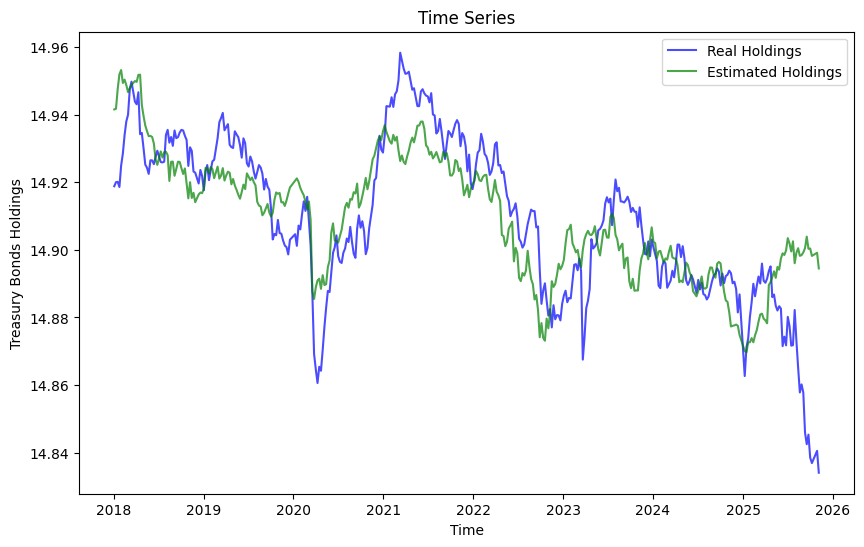

In [18]:
# Create Comparative Plot
plt.figure(figsize=(10, 6))
plt.plot(ols_df_filtered['y'], label='Real Holdings', color='blue', alpha=0.7)
plt.plot(ols_df_filtered['y_hat'], label='Estimated Holdings', color='green', alpha=0.7)

# Config
plt.title('Time Series')
plt.xlabel('Time')
plt.ylabel('Treasury Bonds Holdings')
plt.legend()

# Show
plt.show()

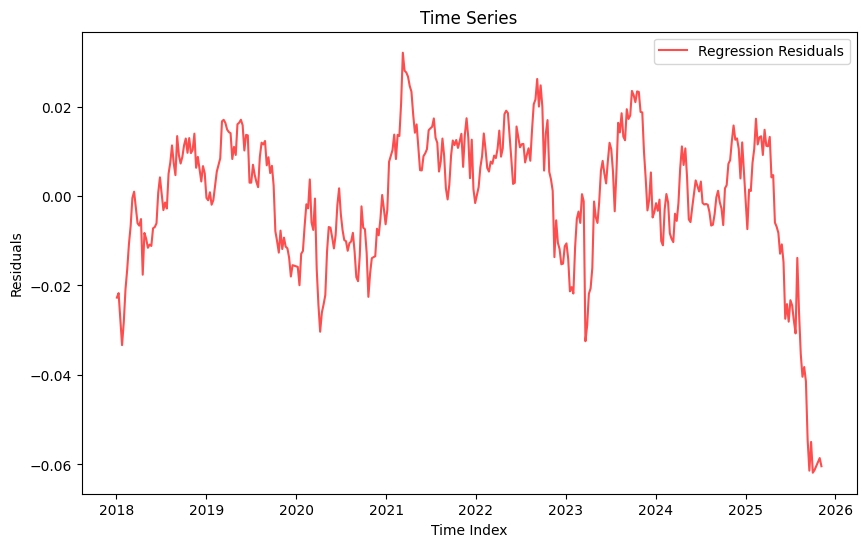

In [19]:
# Plot Residuals
plt.figure(figsize=(10, 6))
plt.plot(ols_df_filtered['residuals'], label='Regression Residuals', color='red', alpha=0.7)

# Config
plt.title('Time Series')
plt.xlabel('Time Index')
plt.ylabel('Residuals')
plt.legend()

# Show
plt.show()

In [20]:
# The Residuals Mean can give us information about the bias of the coefficients
print(f"Residuals Mean: {ols_df_filtered['residuals'].mean().round(3)}")

Residuals Mean: 0.0


The R-Squared Coefficient measures how well our model fits reality:

1) $ R^2=\frac{Var(\hat{y})}{Var(y)} $

In [21]:
# Obtain R-Squared
print(f"Fitted Values Variance: {ols_df_filtered['y_hat'].var()}")
print(f"Real Values Variance: {ols_df_filtered['y'].var()}")

Fitted Values Variance: 0.000321725378164608
Real Values Variance: 0.000556615941880169


In [22]:
# Then the R-Squared Coefficient
r2 = ols_df_filtered['y_hat'].var()/ols_df_filtered['y'].var()

print(f"The R-Squared Coefficient is: {r2}")

The R-Squared Coefficient is: 0.5780024500876955


To evaluate the Model, we need to calculate the Variances of the Beta Coefficients:

1) $ Var(\hat{\beta_0})=\sigma^2(\frac{1}{n}+\frac{\bar{x}^2}{(n-1)Var(x)}) $
2) $ Var(\hat{\beta_1})=\frac{\sigma^2}{nVar(x)} $

In [23]:
# Let us calculate the Slope Standard Deviation
residuals_var = ols_df_filtered['residuals'].var(ddof=1)
x_var = ols_df_filtered['x'].var()
n = len(ols_df_filtered)

print(f"Residuals Variance: {residuals_var}")
print(f"Independent Variable Variance: {x_var}")

Residuals Variance: 0.00023489056371556134
Independent Variable Variance: 0.0017079289130416534


In [24]:
slope_std = np.sqrt(residuals_var)/np.sqrt(n*x_var)

print(f"Slope Coefficient Standard Deviation: {slope_std}")

Slope Coefficient Standard Deviation: 0.018612411098865505


In [25]:
intercept_var = residuals_var * (1/n + ols_df_filtered['x'].mean()**2 / ((n - 1) * x_var))
intercept_std = np.sqrt(intercept_var)

print(f"Intercept Coefficient Standard Deviation: {intercept_std}")

Intercept Coefficient Standard Deviation: 0.0889271512037682


The t-Student Stat is commonly used to test coefficient's statistical significance: 

1) $ t = \frac{\beta}{sse(\beta)} $

In [26]:
# Calculate the t values
slope_t = slope/slope_std
intercept_t = intercept/intercept_std

if abs(slope_t) > 2:
    print(f"The t-value of {slope_t} shows evidence of statistical significance for the slope coefficient")
else:
    print(f"The t-value of {slope_t} shows no evidence of statistical significance for the slope coefficient")

if abs(intercept_t) > 2:
    print(f"The t-value of {intercept_t} shows evidence of statistical significance for the intercept coefficient")
else:
    print(f"The t-value of {intercept_t} shows no evidence of statistical significance for the intercept coefficient")

The t-value of -23.318742586478812 shows evidence of statistical significance for the slope coefficient
The t-value of 190.94653806412796 shows evidence of statistical significance for the intercept coefficient


In [27]:
#Model specification
model = sm.OLS(
    ols_df_filtered['y'], 
    sm.add_constant(ols_df_filtered['x'])
    )   
     
#the results of the model
results = model.fit() 
    
#The Parameters
Beta2 = results.params  

#here we check the summary
print(results.summary())       


                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.578
Model:                            OLS   Adj. R-squared:                  0.577
Method:                 Least Squares   F-statistic:                     541.0
Date:                Wed, 26 Nov 2025   Prob (F-statistic):           5.25e-76
Time:                        20:41:43   Log-Likelihood:                 1095.9
No. Observations:                 397   AIC:                            -2188.
Df Residuals:                     395   BIC:                            -2180.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         16.9803      0.089    190.705      0.0